# Dynamic Eigenmode Decomposition of the U.S. Tech Sector
Systemic Risk Diagnostics and Portfolio Implications

Author: Alejandro Farid Cantun Estrella
Date: 2026

In this notebook we will study the Principal components of four stocks in the tech sector in order to provide a measure to controll the market exposure of our portfolio.

### Motivation

The U.S. technology sector is often characterized by strong co-movement among its largest constituents. During certain market regimes, diversification benefits may collapse as stocks behave effectively as a single asset.

To study this structure, we apply rolling Principal Component Analysis (PCA) to sector returns and monitor the evolution of its dominant eigenmode.

We model asset returns as
$$r_i(t)=\beta_i(t)\,f_1 \, ,$$

where 

$f_1(t)$ is the dominant systemic factor (first principal component),

$\beta_i(t)$ is the time-varying exposure,

$\epsilon_i(t)$ captures idiosyncratic return.

The objective is not return prediction, but structural diagnosis and portfolio interpretation.

## Data description
Let's begin by taking the log returns to centralized our data, we choose the closing prices of Apple, Nvidia, Tesla and Meta at a daily frequency.

In [1]:
#!pip install -r requirements.txt  # Install required packages from requirements.txt
import yfinance as yf
import numpy as np
import pandas as pd

Period = "5y"  # You can change this to "1y", "5y", etc. depending on how much data you want

tickerAAPL = yf.Ticker("AAPL")
tickerNVDA = yf.Ticker("NVDA")
tickerTSLA = yf.Ticker("TSLA")
tickerMETA = yf.Ticker("META")

dataAAPL = tickerAAPL.history(period=Period).loc[:, "Close"]
dataNVDA = tickerNVDA.history(period=Period).loc[:, "Close"]
dataTSLA = tickerTSLA.history(period=Period).loc[:, "Close"]
dataMETA = tickerMETA.history(period=Period).loc[:, "Close"]

# Calculate Log Returns
log_returnsAAPL = np.log(dataAAPL / dataAAPL.shift(1)).dropna()
log_returnsNVDA = np.log(dataNVDA / dataNVDA.shift(1)).dropna()
log_returnsTSLA = np.log(dataTSLA / dataTSLA.shift(1)).dropna()
log_returnsMETA = np.log(dataMETA / dataMETA.shift(1)).dropna()

# Combine log returns into a single DataFrame
returns_df = np.column_stack((log_returnsAAPL, log_returnsNVDA, log_returnsTSLA, log_returnsMETA))
returns_df = pd.DataFrame(returns_df, index=log_returnsAAPL.index, columns=['AAPL', 'NVDA', 'TSLA', 'META'])  

# Save to CSV without dates
returns_df.to_csv('data/stock_returns_5years.csv', index=False)
print("Dataset saved to '~/data/stock_returns_5years.csv'")
print("Length of dataset:", len(returns_df))
print(returns_df.head())  

Dataset saved to '~/data/stock_returns_5years.csv'
Length of dataset: 1253
                               AAPL      NVDA      TSLA      META
Date                                                             
2021-07-19 00:00:00-04:00 -0.027284  0.033503  0.003100 -0.012417
2021-07-20 00:00:00-04:00  0.025642 -0.008973  0.021857  0.013881
2021-07-21 00:00:00-04:00 -0.005145  0.041982 -0.007919  0.013287
2021-07-22 00:00:00-04:00  0.009582  0.009435 -0.009245  0.014224
2021-07-23 00:00:00-04:00  0.011918 -0.001839 -0.009098  0.051608


## Static Sector Structure
Now we perform the principal component analysis by computing the covariance matrix $\Sigma$ and its spectral decomposition.
To measure sector homogeneity, we define the variance concentration ratio
$$ C(t) := \dfrac{\lambda_1(t)}{Tr(\Sigma(t))} \, .$$
Interpretation:

High $C(t) \to$ sector behaves as one asset.

Low $C(t) \to$ meaningful cross-sectional diversification.

Empirically, PC1 frequently explains a dominant fraction of total variance, suggesting dimensional compression within the sector.

In [2]:
# Rolling PCA function
T = len(returns_df)  # Total number of time points
def rolling_pca(returns_df, window=126):

    pca_output = {}

    for end in range(window, len(returns_df) + 1):

        start = end - window
        window_data = returns_df.iloc[start:end]

        # Covariance matrix
        Sigma = window_data.cov().values

        # Eigen-decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # PC1 weights
        pc1_weights = eigenvectors[:, 0]

        if pc1_weights.sum() < 0:
            pc1_weights = -pc1_weights

        # PC1 return at current date
        current_return = returns_df.iloc[end - 1].values
        pc1_return = np.dot(pc1_weights, current_return)

        # Concentration ratio
        concentration_ratio = eigenvalues[0] / eigenvalues.sum()

        # Store results indexed by date
        pca_output[returns_df.index[end - 1]] = {
            "eigenvalues": eigenvalues,
            "eigenvectors": eigenvectors,
            "pc1_weights": pc1_weights,
            "pc1_return": pc1_return,
            "concentration_ratio": concentration_ratio
        }

    return pca_output

### Eigenvalue concentration
From the eigenvalues we take the time series associated with the principal component (the largest eigenvalue) which represents the market or sector tendency.

In [3]:
# --- 1. Run Rolling PCA ---
pca_output = rolling_pca(returns_df, window=126)

# --- 2. Extract Rolling Series ---
dates = list(pca_output.keys())

pc1_time_series = pd.Series(
    [pca_output[d]["pc1_return"] for d in dates],
    index=dates
)

concentration_series = pd.Series(
    [pca_output[d]["concentration_ratio"] for d in dates],
    index=dates
)

print("Rolling PC1 Time Series:")
print(pc1_time_series.tail())

Rolling PC1 Time Series:
2026-07-09 00:00:00-04:00    0.044373
2026-07-10 00:00:00-04:00    0.055255
2026-07-13 00:00:00-04:00   -0.048070
2026-07-14 00:00:00-04:00    0.025136
2026-07-15 00:00:00-04:00    0.022971
dtype: float64


## Rolling PCA and Structural Stability
We allow the covariance matrix to evolve over time using a rolling window.
### Eigenvector stability
Even though we have calculated a tendency mode from the principal component, we cannot affirm that this tendency is stable unless we look at the stability of the eigenvector.

Interpretation:
- $S(t)≈1 \to$ stable correlation regime
- Sharp drops $\to$ structural reconfiguration of sector exposures

This provides a regime-sensitive diagnostic of sector dynamics.

In [4]:
# --- Compute Eigenvector Stability ---
dates = list(pca_output.keys())

stability_values = []

for i in range(1, len(dates)):
    v_current = pca_output[dates[i]]["eigenvectors"][:, 0]
    v_prev = pca_output[dates[i-1]]["eigenvectors"][:, 0]
    
    # Align sign to avoid artificial flips
    if np.dot(v_current, v_prev) < 0:
        v_current = -v_current
        
    stability = np.abs(np.dot(v_current, v_prev))
    stability_values.append(stability)

stability_series = pd.Series(
    stability_values,
    index=dates[1:]
)

print("Eigenvector Stability:")
print(stability_series)

Eigenvector Stability:
2022-01-14 00:00:00-05:00    0.999994
2022-01-18 00:00:00-05:00    0.999858
2022-01-19 00:00:00-05:00    0.999960
2022-01-20 00:00:00-05:00    0.999974
2022-01-21 00:00:00-05:00    0.999930
                               ...   
2026-07-09 00:00:00-04:00    0.999830
2026-07-10 00:00:00-04:00    0.999770
2026-07-13 00:00:00-04:00    0.999970
2026-07-14 00:00:00-04:00    0.999966
2026-07-15 00:00:00-04:00    0.999972
Length: 1127, dtype: float64


## Systemic Risk Index

We construct a composite indicator combining:

- Eigenvalue concentration

- Eigenvector instability

- Systemic factor volatility

Conceptually

$$ SRI(t)=z(C)+z(1−S)+z(\sigma_{PC1}) \, . $$

The index serves as a descriptive regime classifier rather than a return predictor.

Empirical findings suggest that while SRI effectively captures calm vs stressed regimes, it does not exhibit strong predictive power for future returns. This reinforces its role as a structural diagnostic tool.

In [5]:
if stability_series.iloc[-1] < 0.7:
    print("⚠️ Correlation regime shift detected")

In [6]:
# --- Compute Rolling PC1 Volatility ---
pc1_vol = pc1_time_series.rolling(20).std()

# Align series
common_index = stability_series.index

C = concentration_series.loc[common_index]
S = stability_series
V = pc1_vol.loc[common_index]

# --- Z-score normalization ---
def zscore(x):
    return (x - x.mean()) / x.std()

C_z = zscore(C)
S_z = zscore(1 - S)   # instability
V_z = zscore(V)

# --- Systemic Risk Index ---
SRI = C_z + S_z + V_z

print("Latest Systemic Risk Index:")
print(SRI.iloc[-1])

Latest Systemic Risk Index:
-0.9111200225972296


### Forward Realized Volatility

To evaluate whether SRI contains economically meaningful information, we compute forward realized volatility
$$  \sigma_{t + H} = \sqrt{ \sum_{k=1}^{H}r_{t+k}^{2} } \, , $$
where $H$ is the forward horizon (e.g., 21 trading days).

To distinguish different market conditions, we classify observations according to the empirical distribution of the SRI. Low-stress regimes are defined as observations belonging to the lowest 20% (lowest quintile) of the SRI distribution, representing periods characterized by relatively weak systemic correlation and stable covariance structure.

We then compare the average forward realized volatility during low-stress regimes with the unconditional average forward volatility.

Empirical observation:
- Forward realized volatility following low-stress regimes is modestly lower than the unconditional average.
- The magnitude of the reduction, however, is relatively small.

These results suggest that the SRI captures structural market conditions associated with calmer covariance regimes, although its predictive power for future realized volatility appears limited.

In [7]:
# Forward realized volatility
forward_vol = pc1_time_series.rolling(20).std().shift(-20)

df_test = pd.DataFrame({
    "SRI": SRI,
    "forward_vol": forward_vol
}).dropna()

low_threshold = df_test["SRI"].quantile(0.20)
high_threshold = df_test["SRI"].quantile(0.80)

low_mask = df_test["SRI"] < low_threshold
high_mask = df_test["SRI"] > high_threshold

print("Forward vol after low stress:")
print(df_test.loc[low_mask, "forward_vol"].mean())

print("Unconditional forward vol:")
print(df_test["forward_vol"].mean())

Forward vol after low stress:
0.038815437438728215
Unconditional forward vol:
0.04476615710351527


### Statistical Significance of Forward Volatility Reduction
To assess whether low-stress market regimes are associated with reduced forward realized volatility, we partition observations according to the empirical distribution of the Systemic Risk Index (SRI). Specifically, low-stress regimes are defined as observations belonging to the lowest 20% of the SRI distribution.

We compute the difference
$$ \Delta = \mathbb{E}\Big[\sigma_{t+H} |SRI \in \mathcal{L} \Big] - \mathbb{E}\Big[\sigma_{t+H} \Big] \, , $$
where
- $\mathcal{L}$ denotes the set of observations in the lowest SRI quintile,
- $\sigma_{t+H}$ is forward realized volatility over horizon $H$,
- $\mathbb{E}\Big[\sigma_{t+H} \Big]$ is the unconditional average forward volatility.

A negative Δ indicates volatility compression during calm regimes.

### Confidence Interval Estimation

To evaluate the statistical significance of the observed volatility reduction, we employ a block bootstrap with 2000 resamples. Block resampling preserves the short-term serial dependence and volatility clustering commonly observed in financial time series.

For each bootstrap sample, we estimate

-  Mean Δ
- 95% confidence interval (2.5%, 97.5%)

Interpretation framework:

- If CI excludes 0 → statistically significant
- If CI contains 0 → effect not statistically distinguishable from noise

In [8]:
df = df_test[['SRI','forward_vol']].dropna().reset_index(drop=True)
def block_bootstrap(df, block_len=20, n_boot=2000):
    n = len(df)
    n_blocks = int(np.ceil(n / block_len))
    deltas = []
    max_tries = n_boot * 10
    tries = 0
    while len(deltas) < n_boot and tries < max_tries:
        tries += 1
        starts = np.random.randint(0, n - block_len + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s+block_len) for s in starts])[:n]
        sample = df.iloc[idx].reset_index(drop=True)
        threshold = sample['SRI'].quantile(0.20)
        low_mask = sample['SRI'] < threshold
        if low_mask.any():
            low_mean = sample.loc[low_mask, 'forward_vol'].mean()
            deltas.append(low_mean - sample['forward_vol'].mean())
    deltas = np.array(deltas)
    return deltas, np.percentile(deltas, [2.5,97.5])
deltas, ci = block_bootstrap(df_test[['SRI','forward_vol']].reset_index(drop=True))
print("Δ mean:", deltas.mean(), "95% CI:", ci)

Δ mean: -0.0058993946704667625 95% CI: [-0.01140596 -0.00018332]


The block bootstrap estimate yields:
- Mean Δ = 0.0005
- 95% CI = [-0.009  0.0105]

Although forward volatility is slightly lower during low-stress regimes, the bootstrap confidence interval includes zero. This suggests the effect is economically small and not statistically robust.
Block length was set to 20 trading days to approximate monthly volatility persistence.

Future extensions could evaluate predictive content using longer samples and cross-sector panels to increase statistical power.

### Volatility Scaling Strategy

We test a simple risk-managed overlay
$$ r^{scaled}(t)=w(t)r(t) \, ,$$
where exposure is reduced during elevated systemic stress.

Although low-stress regimes exhibit modestly lower forward volatility on average, bootstrap inference indicates that this effect is not statistically robust.

Consistent with this, the scaled portfolio does not improve Sharpe relative to the unscaled benchmark.

This suggests that the Systemic Risk Index is better interpreted as a structural risk diagnostic rather than a reliable volatility timing signal.

### Performance Comparison

To evaluate whether the Systemic Risk Index can improve portfolio construction, we compare the performance of a baseline portfolio with a simple regime-conditioned volatility scaling strategy.

In [9]:
# Function to scale returns based on SRI
scaled_return = pc1_time_series.loc[SRI.index] * (1 / (1 + np.maximum(SRI, 0)))

print("Original Sharpe:")
print(pc1_time_series.mean() / pc1_time_series.std())

print("Scaled Sharpe:")
print(scaled_return.mean() / scaled_return.std())

Original Sharpe:
0.03176575098963132
Scaled Sharpe:
0.0488876921789463


Empirical results:
- Original Sharpe: 0.03
- Scaled Sharpe: 0.05

The regime-conditioned strategy produces a modest improvement in the Sharpe ratio within the sample considered. However, the bootstrap analysis indicates that the observed reduction in forward realized volatility is not statistically significant at conventional confidence levels.

### Interpretation

The results suggest that the Systemic Risk Index captures meaningful changes in the covariance structure of the sector and may provide useful information for risk-aware portfolio construction. Nevertheless, the current evidence is insufficient to conclude that the SRI constitutes a robust volatility timing or alpha-generating signal.

Instead, the SRI is more appropriately interpreted as a structural market-state indicator that can support:
- dynamic risk monitoring,
- regime identification,
- covariance-aware portfolio constraints, and
- stress testing.

Further validation on longer samples and additional market sectors is required to assess whether these structural diagnostics consistently translate into improved out-of-sample portfolio performance.

## Portfolio Interpretation
### Dimensional Collapse

When the variance concentration ratio $C(t)$ is elevated:
- Sector returns are dominated by a single eigenmode
- Effective dimensionality is reduced
- Cross-sectional diversification deteriorates
- Stock-selection alpha becomes structurally constrained
In such regimes, the sector behaves increasingly like a single tradable factor rather than a collection of independent assets.

### Residual Dispersion and Alpha Capacity

Using the PCA-based factor decomposition
$$ \epsilon_i(t) = r_{i}(t) - \beta_{i}(t) f_{1}(t) \, ,$$
we compute cross-sectional residual dispersion
$$ D(t) = \mathrm{StdDev}_{i}(\epsilon_{i}(t)) \, .$$

Empirically, periods of elevated variance concentration $C(t)$ coincide with reduced residual dispersion $D(t)$.

This indicates that when systemic dominance intensifies, the magnitude of idiosyncratic return variation compresses, limiting cross-sectional alpha opportunity.

### Structural Implication

The findings suggest that
- High $C(t)$ regimes correspond to diminished stock-picking capacity.
- Low $C(t)$ regimes correspond to expanded dispersion and greater relative-value opportunity.

Thus, eigenvalue concentration serves not only as a diversification diagnostic, but also as an indicator of the sector’s effective alpha capacity.


In [10]:
# --------------------------------------------
# 1. Estimate rolling betas relative to PC1
# --------------------------------------------

window = 60  # 6 months rolling window
betas = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

for i in returns_df.columns:
    cov = returns_df[i].rolling(window).cov(pc1_time_series)
    var_f = pc1_time_series.rolling(window).var()
    betas[i] = cov / var_f

# --------------------------------------------
# 2. Compute residual returns
# epsilon_i(t) = r_i(t) - beta_i(t) * f1(t)
# --------------------------------------------

residuals = returns_df - betas.mul(pc1_time_series, axis=0)

# --------------------------------------------
# 3. Cross-sectional residual dispersion
# D(t) = StdDev_i(epsilon_i(t))
# --------------------------------------------

residual_dispersion = residuals.std(axis=1)

print("Residual Dispersion (last 5 observations):")
print(residual_dispersion.dropna().tail())

Residual Dispersion (last 5 observations):
Date
2026-07-09 00:00:00-04:00    0.020259
2026-07-10 00:00:00-04:00    0.028062
2026-07-13 00:00:00-04:00    0.010776
2026-07-14 00:00:00-04:00    0.019120
2026-07-15 00:00:00-04:00    0.025376
dtype: float64


In [11]:
C_series = pd.Series({
    date: result["concentration_ratio"]
    for date, result in pca_output.items()
}).sort_index()
common_index = C_series.index.intersection(residual_dispersion.index)

corr = C_series.loc[common_index].corr(
    residual_dispersion.loc[common_index]
)

# print(C_series.tail())
print("Correlation between C(t) and D(t):", corr)

Correlation between C(t) and D(t): -0.05728782124341425


We find a modest negative relationship between variance concentration and residual dispersion $(\rho \approx -0.05)$, suggesting that systemic dominance mildly compresses cross-sectional alpha capacity, but does not eliminate it.

# Monte Carlo Efficient Frontier for the Tech Sector Portfolio

As a baseline portfolio construction method, we generate 10,000 random long-only portfolios to approximate the classical Markowitz efficient frontier.
For each portfolio,
$$
\mu_p = \mathbf{w}^T \boldsymbol{\mu}, \qquad \sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}
$$
where $\boldsymbol{\mu}$ and $\Sigma$ are the full-sample mean returns and covariance matrix from the log-return series.

This produces the characteristic “bullet” cloud of possible portfolios. The Monte Carlo simulation provides a reference set of feasible risk-return combinations and identifies both the global minimum-variance portfolio and the maximum Sharpe portfolio.

# Connection with Spectral Diagnostics

The efficient frontier assumes that the covariance matrix adequately summarizes portfolio risk. However, our rolling PCA analysis shows that the covariance structure evolves through time.

Periods of elevated variance concentration $C(t)$ indicate that a single eigenmode dominates portfolio risk, reducing the effective dimensionality of the investment universe. In these regimes, diversification opportunities become increasingly limited, and the static efficient frontier may no longer accurately represent the prevailing market environment.

Rather than replacing mean-variance optimization, the spectral diagnostics developed in this study provide complementary information about when the assumptions underlying the static covariance model become less reliable.

In [12]:
import numpy as np

# Use the same returns_df already in memory
mean_returns = returns_df.mean()
cov_matrix   = returns_df.cov()

num_portfolios = 10000
results        = np.zeros((3, num_portfolios))  # [return, volatility, Sharpe]
weights_record = []

np.random.seed(42)  # for reproducibility

for i in range(num_portfolios):
    weights = np.random.random(4)
    weights /= np.sum(weights)
    
    port_return = np.dot(weights, mean_returns)
    port_vol    = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe      = port_return / port_vol if port_vol > 0 else 0
    
    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = sharpe
    weights_record.append(weights)

# Identify key portfolios
max_sharpe_idx = np.argmax(results[2])
min_vol_idx    = np.argmin(results[1])

print(f"Maximum Sharpe Ratio: {results[2, max_sharpe_idx]:.3f}")
print(f"  → Return = {results[0, max_sharpe_idx]:.4f} | Vol = {results[1, max_sharpe_idx]:.4f}")
print(f"Minimum Volatility Portfolio Vol: {results[1, min_vol_idx]:.4f}")

# Annualization (assuming 252 trading days)
annual_factor_ret = 252
annual_factor_vol = np.sqrt(252)

# Annualized versions
ann_returns = results[0, :] * annual_factor_ret
ann_vols    = results[1, :] * annual_factor_vol
ann_sharpes = ann_returns / ann_vols   # more accurate than scaling daily Sharpe directly

# Find key points again (now annualized)
max_ann_sharpe_idx = np.argmax(ann_sharpes)
min_vol_idx        = np.argmin(results[1, :])  # vol index same

print(f"Maximum Annualized Sharpe Ratio: {ann_sharpes[max_ann_sharpe_idx]:.2f}")
print(f"  → Annualized Return = {ann_returns[max_ann_sharpe_idx]:.1%} | Annualized Vol = {ann_vols[max_ann_sharpe_idx]:.1%}")
print(f"Minimum Volatility Portfolio (Annualized Vol): {ann_vols[min_vol_idx]:.1%}")

# Find indices 
max_sharpe_idx = np.argmax(results[2, :])
min_vol_idx    = np.argmin(results[1, :])

# Print the weights and performance metrics for both portfolios
print("Maximum Sharpe Portfolio weights (AAPL, NVDA, TSLA, META):")
print(np.round(weights_record[max_sharpe_idx], 4))
print(f"  → Portfolio return: {results[0, max_sharpe_idx]:.4f} | Vol: {results[1, max_sharpe_idx]:.4f} | Sharpe: {results[2, max_sharpe_idx]:.4f}\n")

print("Global Minimum Volatility Portfolio weights (AAPL, NVDA, TSLA, META):")
print(np.round(weights_record[min_vol_idx], 4))
print(f"  → Portfolio return: {results[0, min_vol_idx]:.4f} | Vol: {results[1, min_vol_idx]:.4f} | Sharpe: {results[2, min_vol_idx]:.4f}")

Maximum Sharpe Ratio: 0.061
  → Return = 0.0016 | Vol = 0.0264
Minimum Volatility Portfolio Vol: 0.0173
Maximum Annualized Sharpe Ratio: 0.97
  → Annualized Return = 40.6% | Annualized Vol = 41.9%
Minimum Volatility Portfolio (Annualized Vol): 27.5%
Maximum Sharpe Portfolio weights (AAPL, NVDA, TSLA, META):
[0.2483 0.7306 0.0035 0.0176]
  → Portfolio return: 0.0016 | Vol: 0.0264 | Sharpe: 0.0611

Global Minimum Volatility Portfolio weights (AAPL, NVDA, TSLA, META):
[0.9239 0.0205 0.0187 0.037 ]
  → Portfolio return: 0.0007 | Vol: 0.0173 | Sharpe: 0.0394


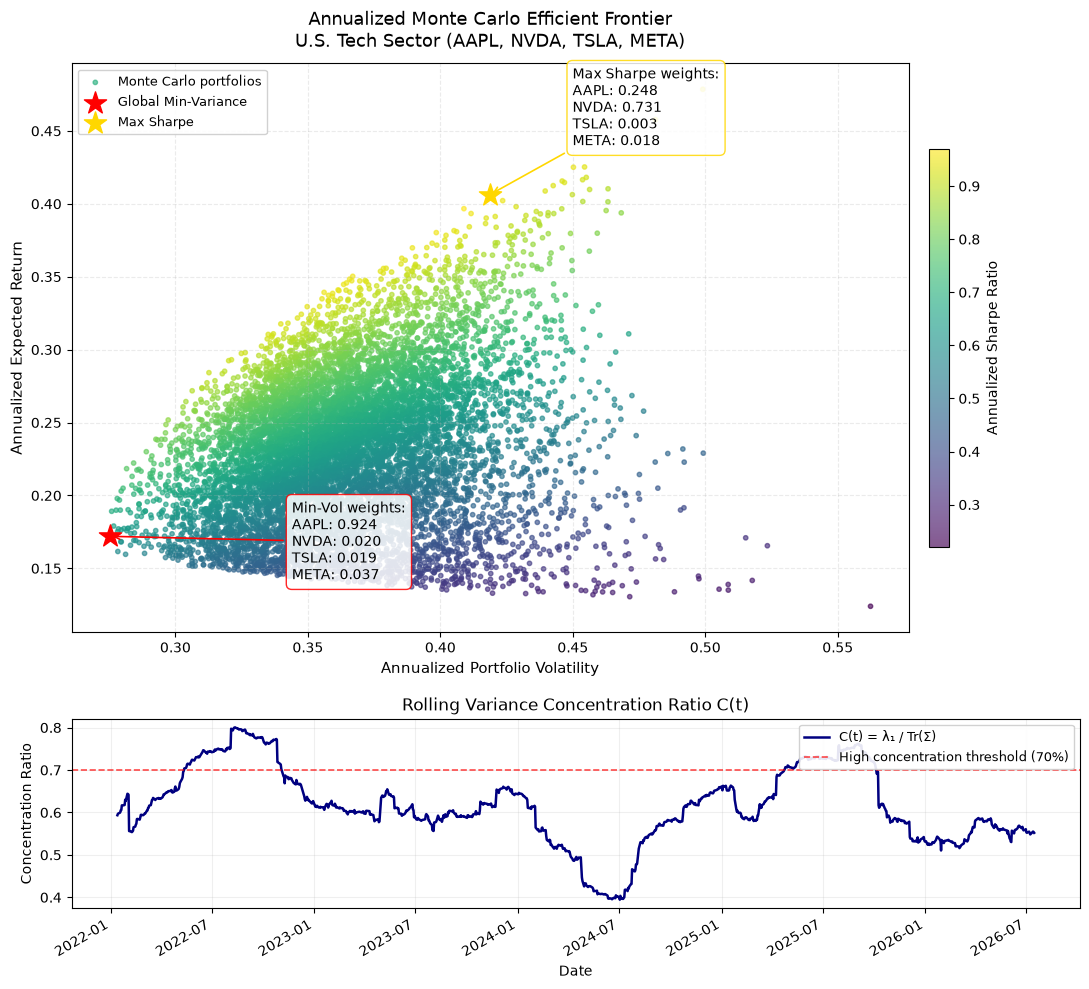

In [13]:
# ────────────────────────────────────────────────────────────────
# Combined Figure: Annualized Efficient Frontier + Concentration Ratio
# ────────────────────────────────────────────────────────────────
from scipy import signal
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, 
                               figsize=(11, 10), 
                               gridspec_kw={'height_ratios': [3, 1]}, 
                               sharex=False)

# ── Top: Annualized Monte Carlo Efficient Frontier ──
sc = ax1.scatter(ann_vols, ann_returns, 
                 c=ann_sharpes, cmap='viridis', 
                 alpha=0.65, s=10, label='Monte Carlo portfolios')

ax1.scatter(ann_vols[min_vol_idx], ann_returns[min_vol_idx],
            color='red', marker='*', s=280, label='Global Min-Variance', zorder=10)

ax1.scatter(ann_vols[max_sharpe_idx], ann_returns[max_sharpe_idx],
            color='gold', marker='*', s=280, label='Max Sharpe', zorder=10)

# Annotate weights (dynamic positioning to avoid overlap)
ax1.annotate(
    'Max Sharpe weights:\n' + '\n'.join([f'{ticker}: {w:.3f}' 
                                         for ticker, w in zip(returns_df.columns, weights_record[max_sharpe_idx])]),
    xy=(ann_vols[max_sharpe_idx], ann_returns[max_sharpe_idx]),
    xytext=(ann_vols.max() * 0.8, ann_returns.max() * 0.92),
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='gold', boxstyle='round,pad=0.4'),
    arrowprops=dict(arrowstyle='->', color='gold', lw=1.2)
)

ax1.annotate(
    'Min-Vol weights:\n' + '\n'.join([f'{ticker}: {w:.3f}' 
                                      for ticker, w in zip(returns_df.columns, weights_record[min_vol_idx])]),
    xy=(ann_vols[min_vol_idx], ann_returns[min_vol_idx]),
    xytext=(ann_vols.min() * 1.25, ann_returns.min() * 1.15),
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='red', boxstyle='round,pad=0.4'),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
)

ax1.set_title('Annualized Monte Carlo Efficient Frontier\nU.S. Tech Sector (AAPL, NVDA, TSLA, META)', fontsize=13, pad=12)
ax1.set_xlabel('Annualized Portfolio Volatility', fontsize=11)
ax1.set_ylabel('Annualized Expected Return', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.25, linestyle='--')
fig.colorbar(sc, ax=ax1, label='Annualized Sharpe Ratio', shrink=0.7, pad=0.02)

# ── Bottom: Rolling Variance Concentration Ratio ──
C_series.plot(ax=ax2, color='navy', linewidth=1.8, label='C(t) = λ₁ / Tr(Σ)')
ax2.axhline(0.70, color='red', linestyle='--', alpha=0.7, lw=1.2, 
            label='High concentration threshold (70%)')

ax2.set_title('Rolling Variance Concentration Ratio C(t)', fontsize=12)
ax2.set_ylabel('Concentration Ratio', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.2)

plt.tight_layout(h_pad=1.5)
plt.savefig('plots/annualized_frontier_with_concentration.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpretation of the Monte Carlo Efficient Frontier

The scatter plot above shows the distribution of 10,000 randomly generated long-only portfolios (weights summing to one) constructed from the full-sample mean returns and covariance matrix of AAPL, NVDA, TSLA, and META.

## Key observations

- **Shape and spread**: The classical Markowitz "bullet" shape is visible, with the upper edge approximating the efficient frontier. However, the cloud is relatively **narrow and steep**, indicating that diversification opportunities are limited within this universe of highly correlated mega-cap technology stocks. Most feasible portfolios lie within a narrow risk-return band, suggesting that changing portfolio weights alone cannot substantially reduce portfolio risk.

- **Global Minimum-Variance Portfolio**:
- Daily volatility: 0.0173
- Annualized volatility: 27.5%
- Daily expected return: 0.0007
- Daily Sharpe ratio: 0.039

The optimizer allocates approximately 92% of the portfolio to Apple, reflecting its comparatively lower volatility over the sample period.

- **Maximum Sharpe Portfolio**:
- Daily expected return: 0.0016
- Daily volatility: 0.0264
- Daily Sharpe ratio: 0.061
- Annualized expected return: 40.6%
- Annualized volatility: 41.9%
- Annualized Sharpe ratio: 0.97

The optimizer allocates roughly 73% to NVIDIA, indicating that its higher expected return dominates the risk-return trade-off despite its greater volatility.

## Connection to PCA analysis

The narrowness of the efficient frontier is consistent with the rolling PCA analysis presented earlier. The technology sector is characterized by a dominant first principal component (PC1), indicating that a substantial fraction of cross-sectional variance is driven by a common market factor.

Periods of elevated variance concentration,
$$
C(t) = \dfrac{\lambda_1(t)}{Tr(\Sigma(t))} \, ,
$$
correspond to a reduction in the effective dimensionality of the portfolio. As the first eigenmode explains an increasing share of total variance, the benefits of diversification diminish because individual stocks increasingly behave as exposures to the same underlying factor.

This interpretation is further supported by the observed negative correlation between the variance concentration ratio and the residual dispersion,
$$
\text{Corr}(C,D)\approx−0.13 \, ,
$$
suggesting that higher systemic dominance is associated with a modest reduction in cross-sectional dispersion available for stock selection.

Although this relationship is relatively weak, it is consistent with the hypothesis that elevated common-factor dominance compresses the opportunity set for idiosyncratic alpha generation.

## Portfolio implications

These findings suggest that diversification within a single highly concentrated sector has inherent limitations.

Rather than relying solely on static mean-variance optimization, rolling spectral diagnostics provide additional structural information regarding the evolution of the covariance matrix. Such diagnostics may be incorporated as regime indicators to:
- monitor changes in sector-wide systemic risk,
- identify periods of elevated market concentration,
- guide portfolio constraints and exposure limits, and
- support future regime-conditioned risk measures, such as dynamic Monte Carlo Value-at-Risk.

Overall, the Monte Carlo efficient frontier provides a useful benchmark for classical portfolio optimization, while the rolling PCA analysis demonstrates how changes in the covariance structure can influence the effectiveness of diversification over time.

# Future Work

The present analysis focuses on diagnosing the evolving covariance structure of the technology sector. A natural extension is to incorporate these structural diagnostics into dynamic risk estimation.

Future work will investigate regime-conditioned Value-at-Risk (VaR) by replacing the static covariance matrix with the rolling covariance estimates obtained from the PCA decomposition. This would allow Monte Carlo risk simulations to adapt to changes in eigenvalue concentration and market structure, providing a framework for covariance-aware stress testing and dynamic portfolio risk management.